# GPT-2 Training on Rakitra Dataset

Complete training pipeline for fine-tuning GPT-2 on the Rakitra (Malagasy text) dataset with Weights & Biases monitoring.

**Sections:**
1. Imports and Setup
2. Data Exploration
3. Data Cleaning
4. Tokenization
5. Model Initialization
6. Training Setup with W&B
7. Training
8. Evaluation
9. Testing and Text Generation
10. Summary

## Section 1: Imports and Setup

In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import re
from datasets import Dataset, DatasetDict
from transformers import (
    GPT2Tokenizer,
    GPT2LMHeadModel,
    GPT2Config,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
)
import torch
import wandb
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set WandB API key for Kaggle
os.environ['WANDB_API_KEY'] = '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'

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Imports successful!")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"PyTorch version: {torch.__version__}")

2026-02-12 20:39:27.223879: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770928767.409453      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770928767.510260      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770928767.966076      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770928767.966114      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770928767.966117      24 computation_placer.cc:177] computation placer alr

Imports successful!
Device: Tesla T4
PyTorch version: 2.8.0+cu126


In [3]:
# Configuration
CONFIG = {
    'data_path': '/kaggle/input/rakitra/rakitra.csv',  # Update this path for Kaggle
    'output_dir': './gpt2-rakitra-model',
    'model_name': 'gpt2',  # Options: gpt2, gpt2-medium, gpt2-large, gpt2-xl
    'max_length': 256,
    'train_split': 0.9,
    'val_split': 0.05,
    'test_split': 0.05,
    'batch_size': 8,
    'learning_rate': 5e-5,
    'num_epochs': 3,
    'warmup_steps': 500,
    'save_steps': 1000,
    'logging_steps': 100,
    'max_samples': None,  # Set to int (e.g., 10000) for quick testing
}

print("="*80)
print("CONFIGURATION")
print("="*80)
print(json.dumps(CONFIG, indent=2))
print("="*80)

CONFIGURATION
{
  "data_path": "/kaggle/input/rakitra/rakitra.csv",
  "output_dir": "./gpt2-rakitra-model",
  "model_name": "gpt2",
  "max_length": 256,
  "train_split": 0.9,
  "val_split": 0.05,
  "test_split": 0.05,
  "batch_size": 8,
  "learning_rate": 5e-05,
  "num_epochs": 3,
  "warmup_steps": 500,
  "save_steps": 1000,
  "logging_steps": 100,
  "max_samples": null
}


## Section 2: Data Exploration

In [4]:
def explore_data(file_path, sample_size=10000):
    """Explore the dataset and visualize statistics"""
    print(f"Loading data from: {file_path}")
    
    # Read the CSV file
    print("Reading CSV file...")
    try:
        df = pd.read_csv(file_path, nrows=sample_size if CONFIG['max_samples'] is None else CONFIG['max_samples'])
    except Exception as e:
        print(f"Error reading CSV: {e}")
        return None
    
    print(f"\nDataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    # Display first few rows
    print("\n--- First 3 rows ---")
    display(df.head(3))
    
    # Check for missing values
    print("\n--- Missing values ---")
    print(df.isnull().sum())
    
    # Text statistics
    if 'text' in df.columns:
        df['text_length'] = df['text'].astype(str).apply(len)
        df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
        
        print("\n--- Text Statistics ---")
        print(f"Total texts: {len(df)}")
        print(f"Average text length (chars): {df['text_length'].mean():.2f}")
        print(f"Median text length (chars): {df['text_length'].median():.2f}")
        print(f"Average word count: {df['word_count'].mean():.2f}")
        print(f"Median word count: {df['word_count'].median():.2f}")
        print(f"Min text length: {df['text_length'].min()}")
        print(f"Max text length: {df['text_length'].max()}")
        
        # Plot distributions
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Character length distribution
        axes[0].hist(df['text_length'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[0].set_xlabel('Text Length (characters)', fontsize=12)
        axes[0].set_ylabel('Frequency', fontsize=12)
        axes[0].set_title('Distribution of Text Lengths', fontsize=14, fontweight='bold')
        axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
        axes[0].axvline(df['text_length'].median(), color='green', linestyle='--', linewidth=2, label='Median')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        # Word count distribution
        axes[1].hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7, color='coral')
        axes[1].set_xlabel('Word Count', fontsize=12)
        axes[1].set_ylabel('Frequency', fontsize=12)
        axes[1].set_title('Distribution of Word Counts', fontsize=14, fontweight='bold')
        axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
        axes[1].axvline(df['word_count'].median(), color='green', linestyle='--', linewidth=2, label='Median')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('data_exploration.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("\nSaved visualization to: data_exploration.png")
        
        # Sample texts
        print("\n--- Sample Texts ---")
        for i, text in enumerate(df['text'].head(3), 1):
            print(f"\nSample {i}:")
            print("-" * 80)
            print(f"{str(text)[:300]}...")
            print("-" * 80)
    
    return df

Loading data from: /kaggle/input/rakitra/rakitra.csv
Reading CSV file...

Dataset shape: (10000, 1)
Columns: ['text']

--- First 3 rows ---


,text
0,Hiverina ho zanatany amin’ny endriny maoderina...
1,Mbola hisy fanantenana ve ny ho havin’i Madaga...
2,Mitohy hatrany ny fanilatsilahana ny vahoaka k...



--- Missing values ---
text    0
dtype: int64

--- Text Statistics ---
Total texts: 10000
Average text length (chars): 1582.99
Median text length (chars): 1389.00
Average word count: 217.22
Median word count: 189.00
Min text length: 275
Max text length: 10400


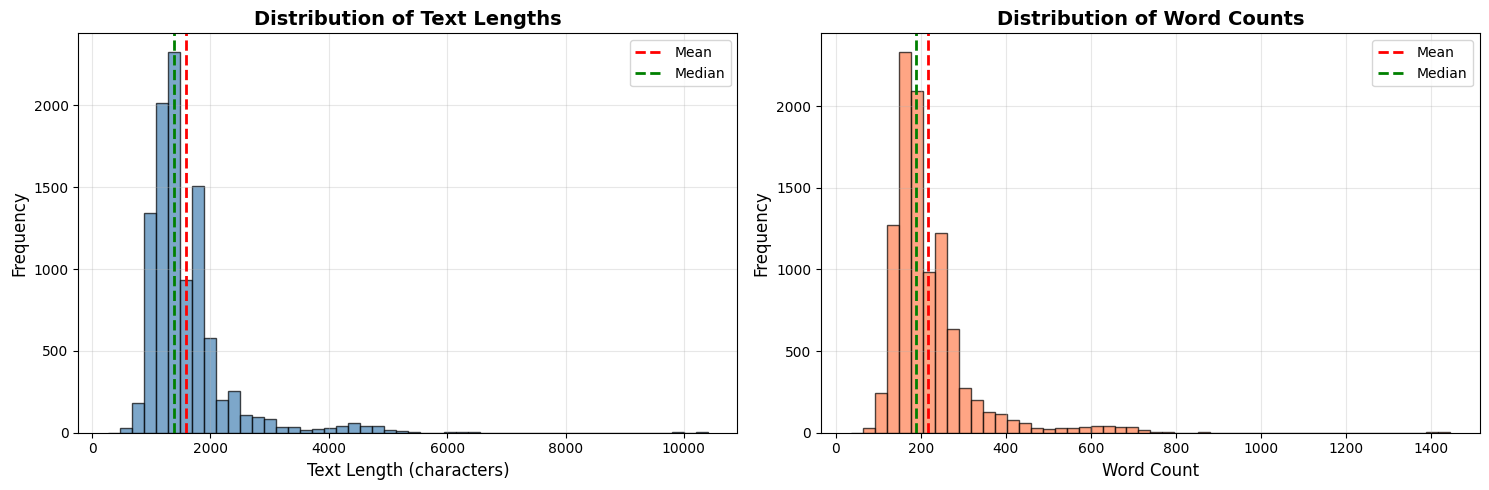


Saved visualization to: data_exploration.png

--- Sample Texts ---

Sample 1:
--------------------------------------------------------------------------------
Hiverina ho zanatany amin’ny endriny maoderina i Madagasikara, raha ho tafapetraka amboletra amin’ny fomba ofisialy ihany ny filoha napetraky ny CENI sy ny HCC tsy ara-drariny sy tsy ara-dalàna Andry Rajoelina, amin’ny 16 desambra ho avy izao. Ny antony dia satria olona tsy mizaka ny zom-pirenena Ma...
--------------------------------------------------------------------------------

Sample 2:
--------------------------------------------------------------------------------
Mbola hisy fanantenana ve ny ho havin’i Madagasikara raha izao zavamisy eto amin’ny firenena izao no sainina sy eritreretina? Tany tan-dalàna ve no misy eto Madagasikara sa tsia, satria toa izay tian’ireo tompom-pahefana no hampiharina hitondràna ny firenena? Tena manao ny danin’ny kibony izy ireo, ...
-----------------------------------------------------------

In [5]:
# Run exploration
explored_df = explore_data(CONFIG['data_path'], sample_size=10000)

## Section 3: Data Cleaning and Preprocessing

In [6]:
def clean_text(text):
    """Clean and preprocess text"""
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Strip leading/trailing whitespace
    text = text.strip()
    
    # Remove very short texts (less than 1 character)
    if len(text) < 1:
        return ""
    
    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    
    # Remove html tags
    text = re.sub(r'<.*?>', '', text)
    
    return text

In [7]:
def load_and_clean_data(file_path, max_samples=None):
    """Load and clean the full dataset"""
    print(f"Loading full dataset from: {file_path}")
    
    # Load data in chunks to handle large file
    chunk_size = 50000
    chunks = []
    
    print("Reading and cleaning data in chunks...")
    for chunk in tqdm(pd.read_csv(file_path, chunksize=chunk_size, nrows=max_samples)):
        # Clean texts
        chunk['text'] = chunk['text'].apply(clean_text)
        # Remove empty texts
        chunk = chunk[chunk['text'] != ""]
        chunks.append(chunk)
    
    # Combine chunks
    df = pd.concat(chunks, ignore_index=True)
    
    print(f"\nCleaned dataset shape: {df.shape}")
    return df

In [8]:
# Load and clean the full dataset
print("="*80)
print("DATA CLEANING")
print("="*80)
df_clean = load_and_clean_data(CONFIG['data_path'], max_samples=CONFIG['max_samples'])

DATA CLEANING
Loading full dataset from: /kaggle/input/rakitra/rakitra.csv
Reading and cleaning data in chunks...


6it [01:01, 10.25s/it]


Cleaned dataset shape: (255109, 1)


In [9]:
# Create train/val/test splits
print("\nCreating train/val/test splits...")
train_size = int(len(df_clean) * CONFIG['train_split'])
val_size = int(len(df_clean) * CONFIG['val_split'])

# Shuffle data
df_shuffled = df_clean.sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df = df_shuffled[:train_size]
val_df = df_shuffled[train_size:train_size + val_size]
test_df = df_shuffled[train_size + val_size:]

print(f"\nTrain size: {len(train_df):,}")
print(f"Validation size: {len(val_df):,}")
print(f"Test size: {len(test_df):,}")


Creating train/val/test splits...

Train size: 229,598
Validation size: 12,755
Test size: 12,756


## Section 4: Tokenization

In [10]:
# Initialize tokenizer
print("="*80)
print("TOKENIZATION")
print("="*80)
print(f"Loading tokenizer: {CONFIG['model_name']}")
tokenizer = GPT2Tokenizer.from_pretrained(CONFIG['model_name'])

# Add padding token (GPT-2 doesn't have one by default)
tokenizer.pad_token = tokenizer.eos_token

print(f"Vocabulary size: {len(tokenizer):,}")
print(f"Max length: {CONFIG['max_length']}")

TOKENIZATION
Loading tokenizer: gpt2


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Vocabulary size: 50,257
Max length: 256


In [11]:
def tokenize_function(examples):
    """Tokenize texts"""
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=CONFIG['max_length'],
        padding='max_length',
        return_tensors=None
    )

In [12]:
# Convert to HuggingFace datasets
print("\nConverting to HuggingFace datasets...")
train_dataset = Dataset.from_pandas(train_df[['text']])
val_dataset = Dataset.from_pandas(val_df[['text']])
test_dataset = Dataset.from_pandas(test_df[['text']])

# Tokenize datasets
print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
val_dataset = val_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
test_dataset = test_dataset.map(tokenize_function, batched=True, remove_columns=['text'])

print(f"\nTrain dataset: {len(train_dataset):,} samples")
print(f"Validation dataset: {len(val_dataset):,} samples")
print(f"Test dataset: {len(test_dataset):,} samples")


Converting to HuggingFace datasets...
Tokenizing datasets...


Map:   0%|          | 0/229598 [00:00<?, ? examples/s]

Map:   0%|          | 0/12755 [00:00<?, ? examples/s]

Map:   0%|          | 0/12756 [00:00<?, ? examples/s]


Train dataset: 229,598 samples
Validation dataset: 12,755 samples
Test dataset: 12,756 samples


## Section 5: Model Initialization

In [13]:
# Load pre-trained GPT-2 model
print("="*80)
print("MODEL INITIALIZATION")
print("="*80)
print(f"Loading model: {CONFIG['model_name']}")
model = GPT2LMHeadModel.from_pretrained(CONFIG['model_name'])

# Model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Data collator for language modeling
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # GPT-2 is causal LM, not masked LM
)

print("Data collator initialized")

MODEL INITIALIZATION
Loading model: gpt2


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Total parameters: 124,439,808
Trainable parameters: 124,439,808
Data collator initialized


## Section 6: Training Setup with Weights & Biases

In [14]:
# Initialize Weights & Biases
print("="*80)
print("TRAINING SETUP WITH WEIGHTS & BIASES")
print("="*80)
print("Initializing Weights & Biases...")
wandb.init(
    project="gpt2-rakitra",
    name=f"gpt2-rakitra-{pd.Timestamp.now().strftime('%Y%m%d-%H%M%S')}",
    config=CONFIG
)
print("W&B initialized successfully!")

TRAINING SETUP WITH WEIGHTS & BIASES
Initializing Weights & Biases...


wandb: Currently logged in as: kimbohy (kimbohy-lova) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run sn3ujgvf
wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260212_205910-sn3ujgvf
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run gpt2-rakitra-20260212-205909
wandb: ⭐️ View project at https://wandb.ai/kimbohy-lova/gpt2-rakitra
wandb: 🚀 View run at https://wandb.ai/kimbohy-lova/gpt2-rakitra/runs/sn3ujgvf


W&B initialized successfully!


In [15]:
# Training arguments
training_args = TrainingArguments(
    output_dir=CONFIG['output_dir'],
    overwrite_output_dir=True,
    num_train_epochs=CONFIG['num_epochs'],
    per_device_train_batch_size=CONFIG['batch_size'],
    per_device_eval_batch_size=CONFIG['batch_size'],
    learning_rate=CONFIG['learning_rate'],
    warmup_steps=CONFIG['warmup_steps'],
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=CONFIG['logging_steps'],
    eval_strategy="steps",
    eval_steps=CONFIG['save_steps'],
    save_steps=CONFIG['save_steps'],
    save_total_limit=3,
    report_to="wandb",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
    gradient_accumulation_steps=2,
    seed=SEED,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

print("Training configuration:")
print(f"  Total epochs: {CONFIG['num_epochs']}")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  Warmup steps: {CONFIG['warmup_steps']}")
print(f"  Mixed precision: {torch.cuda.is_available()}")
print("Trainer initialized!")

Training configuration:
  Total epochs: 3
  Batch size: 8
  Learning rate: 5e-05
  Warmup steps: 500
  Mixed precision: True
Trainer initialized!


## Section 7: Training

**Note:** This will take time depending on your hardware. Monitor progress on your W&B dashboard.

In [16]:
print("="*80)
print("STARTING TRAINING")
print("="*80)
print("Monitor training at: https://wandb.ai")
print("="*80)

# Train the model
train_result = trainer.train()

# Save training metrics
print("\n" + "="*80)
print("TRAINING COMPLETED!")
print("="*80)
print(f"Training loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f}s ({train_result.metrics['train_runtime']/60:.2f} min)")
print(f"Training samples/second: {train_result.metrics['train_samples_per_second']:.2f}")
print("="*80)

STARTING TRAINING
Monitor training at: https://wandb.ai


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
1000,2.194500,2.091208
2000,1.980200,1.888149
3000,1.895000,1.799991
4000,1.821500,1.739492
5000,1.754700,1.698145
6000,1.721600,1.665465
7000,1.724800,1.639933
8000,1.700200,1.617861
9000,1.640100,1.599987
10000,1.648900,1.584903


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].



TRAINING COMPLETED!
Training loss: 1.7387
Training time: 39562.04s (659.37 min)
Training samples/second: 17.41


In [17]:
# Save the final model
print("\nSaving final model...")
trainer.save_model(CONFIG['output_dir'])
tokenizer.save_pretrained(CONFIG['output_dir'])
print(f"Model saved to: {CONFIG['output_dir']}")


Saving final model...
Model saved to: ./gpt2-rakitra-model


## Section 8: Evaluation on Test Set

In [18]:
print("="*80)
print("EVALUATION ON TEST SET")
print("="*80)

print("Evaluating on test set...")
eval_results = trainer.evaluate(test_dataset)

print("\n--- Test Results ---")
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}")

# Log to wandb
wandb.log({"test_loss": eval_results['eval_loss']})
print("\nTest evaluation complete!")

EVALUATION ON TEST SET
Evaluating on test set...



--- Test Results ---
  eval_loss: 1.5173
  eval_runtime: 258.5745
  eval_samples_per_second: 49.3320
  eval_steps_per_second: 3.0860
  epoch: 3.0000

Test evaluation complete!


## Section 9: Testing and Text Generation

In [19]:
def generate_text(prompt, max_length=200, num_return_sequences=3, temperature=0.8, top_k=50, top_p=0.95):
    """Generate text using the trained model"""
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # Move to same device as model
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Generate
    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'],
            max_length=max_length,
            num_return_sequences=num_return_sequences,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    # Decode
    generated_texts = [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]
    return generated_texts

In [20]:
# Test with sample prompts
print("="*80)
print("TESTING TEXT GENERATION")
print("="*80)

test_prompts = [
    "Hiverina ho zanatany amin'ny endriny maoderina i Madagasikara",
    "Ny firenena Malagasy",
    "Amin'ny vanim-potoana",
]

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n{'='*80}")
    print(f"PROMPT {i}: {prompt}")
    print(f"{'='*80}")
    
    generated = generate_text(prompt, max_length=150, num_return_sequences=2)
    
    for j, text in enumerate(generated, 1):
        print(f"\nGeneration {j}:")
        print("-" * 80)
        print(text)
        print("-" * 80)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


TESTING TEXT GENERATION

PROMPT 1: Hiverina ho zanatany amin'ny endriny maoderina i Madagasikara

Generation 1:
--------------------------------------------------------------------------------
Hiverina ho zanatany amin'ny endriny maoderina i Madagasikara. Eo koa ny sakafo malagasy ary ny fahaizana mivantana amin'ny alalan'ny fitaterana efa hafatra hifandray amin'ny alalan'ny famaranana izany tamin'ny taona 2018. Ny alalan'ny famaranana ny fandaharam-potoana nifandimby indrindra tamin'ny taona 2019 izay hiarahana mivantana amin'ny fandaharam-potoana f
--------------------------------------------------------------------------------

Generation 2:
--------------------------------------------------------------------------------
Hiverina ho zanatany amin'ny endriny maoderina i Madagasikara ny alahady teo. Vao ny taona 2015 no nahitana karazana maro ny fahatongavana. Ny karazana mpamokatra sarimihetsika na karazana vita maro eo an-toerana dia ny karazana namokatra sarimihetsika na fahatongav

In [21]:
# Log sample generations to wandb
sample_table = wandb.Table(columns=["prompt", "generation"])
for prompt in test_prompts:
    generated = generate_text(prompt, max_length=150, num_return_sequences=1)
    sample_table.add_data(prompt, generated[0])

wandb.log({"sample_generations": sample_table})
print("\nSample generations logged to W&B")


Sample generations logged to W&B


## Section 10: Summary

We successfully fine-tuned GPT-2 on the Rakitra dataset. The model can generate approximately Malagasy text. It is not perfect, but it captures some of the language patterns. Future work could include more data, longer training, and hyperparameter tuning for better results.